1. Import Libraries

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split



2. Load and Understand Data Set

In [73]:
df = pd.read_csv('UCI_Wine_Dataset_178.csv')

In [74]:
df.head(5)

,Id,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,2,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,3,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,4,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,5,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [75]:
df.drop(columns="Id", inplace = True)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid                     178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280_OD315_of_diluted_wines  178 non-null    float64
 13  Proli

In [77]:
df.describe()

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [78]:
df ['class'].value_counts()

,count
class,
2,71
1,59
3,48


Visualize the Data




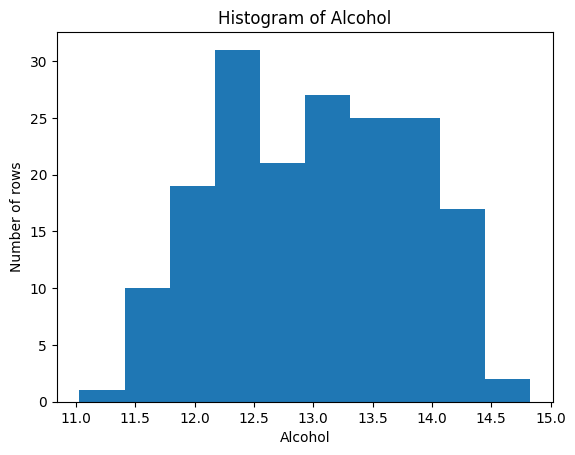

In [79]:
plt.hist(df['Alcohol'])
plt.xlabel('Alcohol')
plt.ylabel('Number of rows')
plt.title('Histogram of Alcohol')
plt.show()

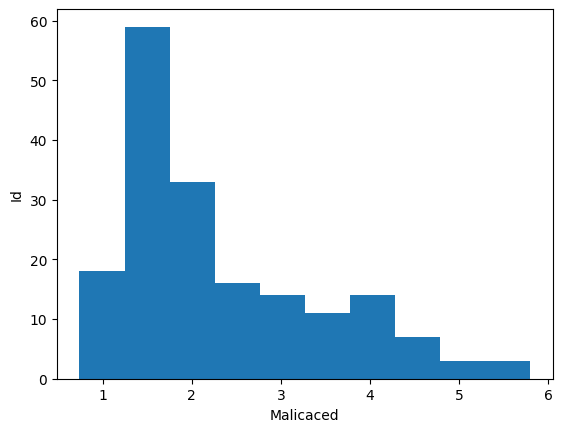

In [80]:
plt.hist(df["Malicacid"])
plt.xlabel("Malicaced")
plt.ylabel("Id")
plt.show()

In [81]:
colors = {1: 'red',
          2: 'blue',
          3: 'green'}

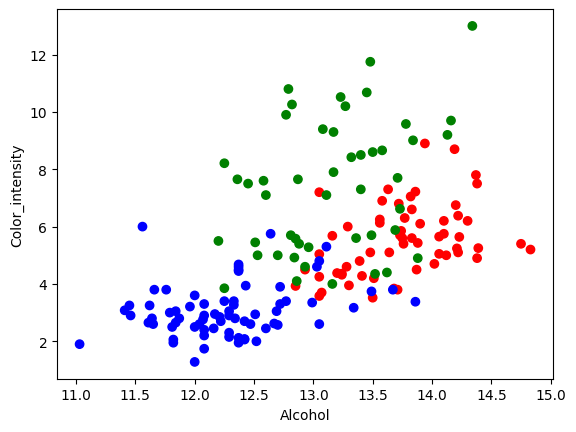

In [82]:
plt.scatter(df['Alcohol'],
            df['Color_intensity'],
            c=df['class'].map(colors))

plt.xlabel("Alcohol")
plt.ylabel("Color_intensity")
plt.show()

FEATURE SELECTION

In [83]:
from sklearn.feature_selection import f_classif

X = df.drop("class", axis = 1)
y = df["class"]

In [84]:
F, p = f_classif(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": F,
    "p_value": p
})

feature_scores = feature_scores.sort_values(
    "F_Score",
    ascending=False
)

feature_scores

,Feature,F_Score,p_value
6,Flavanoids,233.925873,3.598586e-50
12,Proline,207.920374,5.783168e-47
11,OD280_OD315_of_diluted_wines,189.972321,1.393105e-44
0,Alcohol,135.077624,3.319504e-36
9,Color_intensity,120.664018,1.162008e-33
10,Hue,101.316795,5.917662e-30
5,Total_phenols,93.733010,2.137670e-28
1,Malicacid,36.943425,4.127229e-14
3,Alcalinity_of_ash,35.771637,9.444473e-14
8,Proanthocyanins,30.271383,5.125359e-12


In [85]:
top_features = feature_scores.head(5)

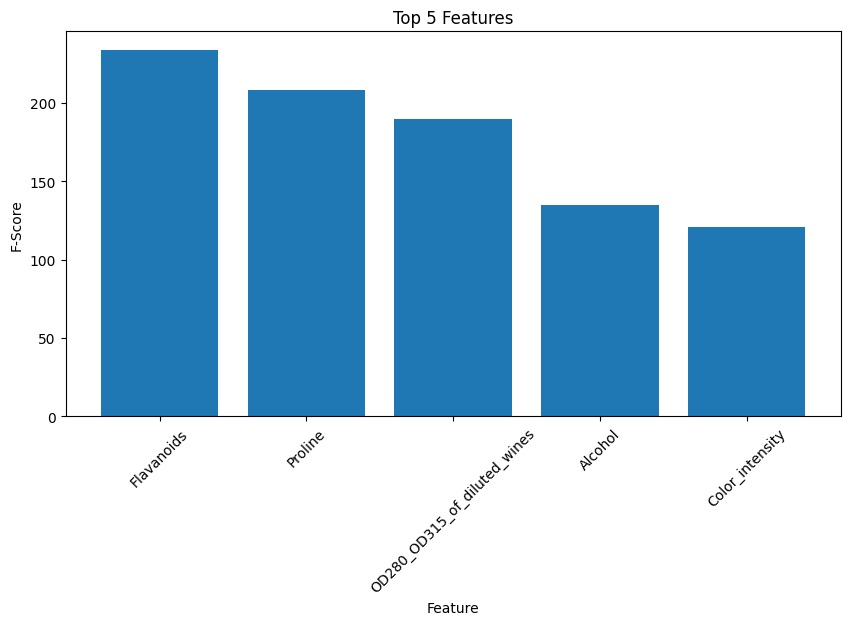

In [86]:
plt.figure(figsize=(10,5))

plt.bar(
    top_features["Feature"],
    top_features["F_Score"]
)

plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("F-Score")
plt.title("Top 5 Features")
plt.show()

Split the dataset

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142,)
(36,)


Create The Model

In [88]:
knn = KNeighborsClassifier(n_neighbors=13)

Train the Model

In [89]:
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=13)

Predict the classes of the test data

In [90]:
y_pred = knn.predict(X_test)

Compute and display model accuracy





In [91]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.6944444444444444


Display the confusion matrix



In [92]:
metrics.confusion_matrix(y_test, y_pred)

array([[13,  0,  4],
       [ 2,  7,  2],
       [ 2,  1,  5]])

Predict the classes of the test data


In [93]:
y_pred = knn.predict(X_test)


Accuracy

In [94]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.6944444444444444


Precision


In [95]:
precision = metrics.precision_score(y_test, y_pred, average='weighted')
print('\nPrecision:', precision)


Precision: 0.7294823232323232


Recall

In [96]:
recall = metrics.recall_score(y_test, y_pred, average='weighted')
print('\nRecall:', recall)


Recall: 0.6944444444444444


F1-Score

In [97]:
f1 = metrics.f1_score(y_test, y_pred, average='weighted')
print('\nF1-Score:', f1)
knn.predict = [[14.23, 1.71, 2.43, 15.6, 127.0, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]]


F1-Score: 0.7032163742690059


Prediction

In [98]:
prediction = knn.predict([[14.23, 1.71, 2.43, 15.6, 127.0, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]])

print('Predicted Wine Class:', prediction[0])


TypeError: 'list' object is not callable